# 1. Data Loading and Inspection

In this section, I load the phishing website dataset and inspect its structure, columns, missing values, duplicates, and target distribution.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("5.urldata.csv")

df.head()

,Domain,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
0,graphicriver.net,0,0,1,1,0,0,0,0,0,1,1,1,0,0,1,0,0
1,ecnavi.jp,0,0,1,1,1,0,0,0,0,1,1,1,0,0,1,0,0
2,hubpages.com,0,0,1,1,0,0,0,0,0,1,0,1,0,0,1,0,0
3,extratorrent.cc,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0
4,icicibank.com,0,0,1,3,0,0,0,0,0,1,0,1,0,0,1,0,0


In [3]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns)

Dataset shape: (10000, 18)

Columns:
Index(['Domain', 'Have_IP', 'Have_At', 'URL_Length', 'URL_Depth',
       'Redirection', 'https_Domain', 'TinyURL', 'Prefix/Suffix', 'DNS_Record',
       'Web_Traffic', 'Domain_Age', 'Domain_End', 'iFrame', 'Mouse_Over',
       'Right_Click', 'Web_Forwards', 'Label'],
      dtype='object')


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Domain         10000 non-null  object
 1   Have_IP        10000 non-null  int64 
 2   Have_At        10000 non-null  int64 
 3   URL_Length     10000 non-null  int64 
 4   URL_Depth      10000 non-null  int64 
 5   Redirection    10000 non-null  int64 
 6   https_Domain   10000 non-null  int64 
 7   TinyURL        10000 non-null  int64 
 8   Prefix/Suffix  10000 non-null  int64 
 9   DNS_Record     10000 non-null  int64 
 10  Web_Traffic    10000 non-null  int64 
 11  Domain_Age     10000 non-null  int64 
 12  Domain_End     10000 non-null  int64 
 13  iFrame         10000 non-null  int64 
 14  Mouse_Over     10000 non-null  int64 
 15  Right_Click    10000 non-null  int64 
 16  Web_Forwards   10000 non-null  int64 
 17  Label          10000 non-null  int64 
dtypes: int64(17), object(1)
mem

In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5626


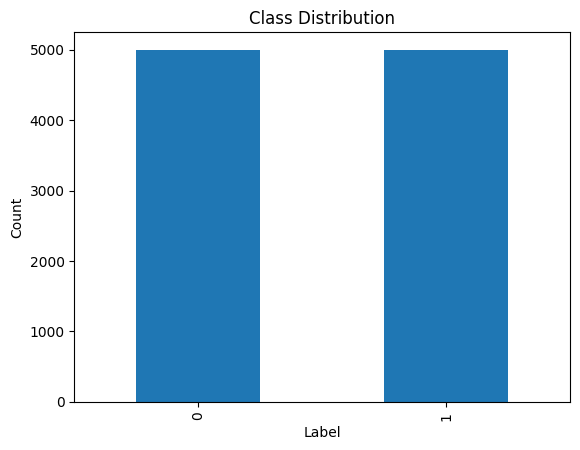

In [8]:
df["Label"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# 2. Basic Statistical Analysis

In [9]:
df.describe()

,Have_IP,Have_At,URL_Length,URL_Depth,Redirection,https_Domain,TinyURL,Prefix/Suffix,DNS_Record,Web_Traffic,Domain_Age,Domain_End,iFrame,Mouse_Over,Right_Click,Web_Forwards,Label
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000
mean,0.005500,0.022600,0.773400,3.072000,0.013500,0.000200,0.090300,0.093200,0.100800,0.845700,0.413700,0.8099,0.090900,0.06660,0.99930,0.105300,0.500000
std,0.073961,0.148632,0.418653,2.128631,0.115408,0.014141,0.286625,0.290727,0.301079,0.361254,0.492521,0.3924,0.287481,0.24934,0.02645,0.306955,0.500025
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.00000,0.00000,0.000000,0.000000
25%,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.0000,0.000000,0.00000,1.00000,0.000000,0.000000
50%,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.0000,0.000000,0.00000,1.00000,0.000000,0.500000
75%,0.000000,0.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.0000,0.000000,0.00000,1.00000,0.000000,1.000000
max,1.000000,1.000000,1.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000,1.000000,1.00000,1.00000,1.000000,1.000000


In [24]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Have_IP,10000.0,0.0055,0.073961,0.0,0.0,0.0,0.0,1.0
Have_At,10000.0,0.0226,0.148632,0.0,0.0,0.0,0.0,1.0
URL_Length,10000.0,0.7734,0.418653,0.0,1.0,1.0,1.0,1.0
URL_Depth,10000.0,3.0720,2.128631,0.0,2.0,3.0,4.0,20.0
Redirection,10000.0,0.0135,0.115408,0.0,0.0,0.0,0.0,1.0
https_Domain,10000.0,0.0002,0.014141,0.0,0.0,0.0,0.0,1.0
TinyURL,10000.0,0.0903,0.286625,0.0,0.0,0.0,0.0,1.0
Prefix/Suffix,10000.0,0.0932,0.290727,0.0,0.0,0.0,0.0,1.0
DNS_Record,10000.0,0.1008,0.301079,0.0,0.0,0.0,0.0,1.0
Web_Traffic,10000.0,0.8457,0.361254,0.0,1.0,1.0,1.0,1.0


### Feature Data Types

In [10]:
df.dtypes

,0
Domain,object
Have_IP,int64
Have_At,int64
URL_Length,int64
URL_Depth,int64
Redirection,int64
https_Domain,int64
TinyURL,int64
Prefix/Suffix,int64
DNS_Record,int64


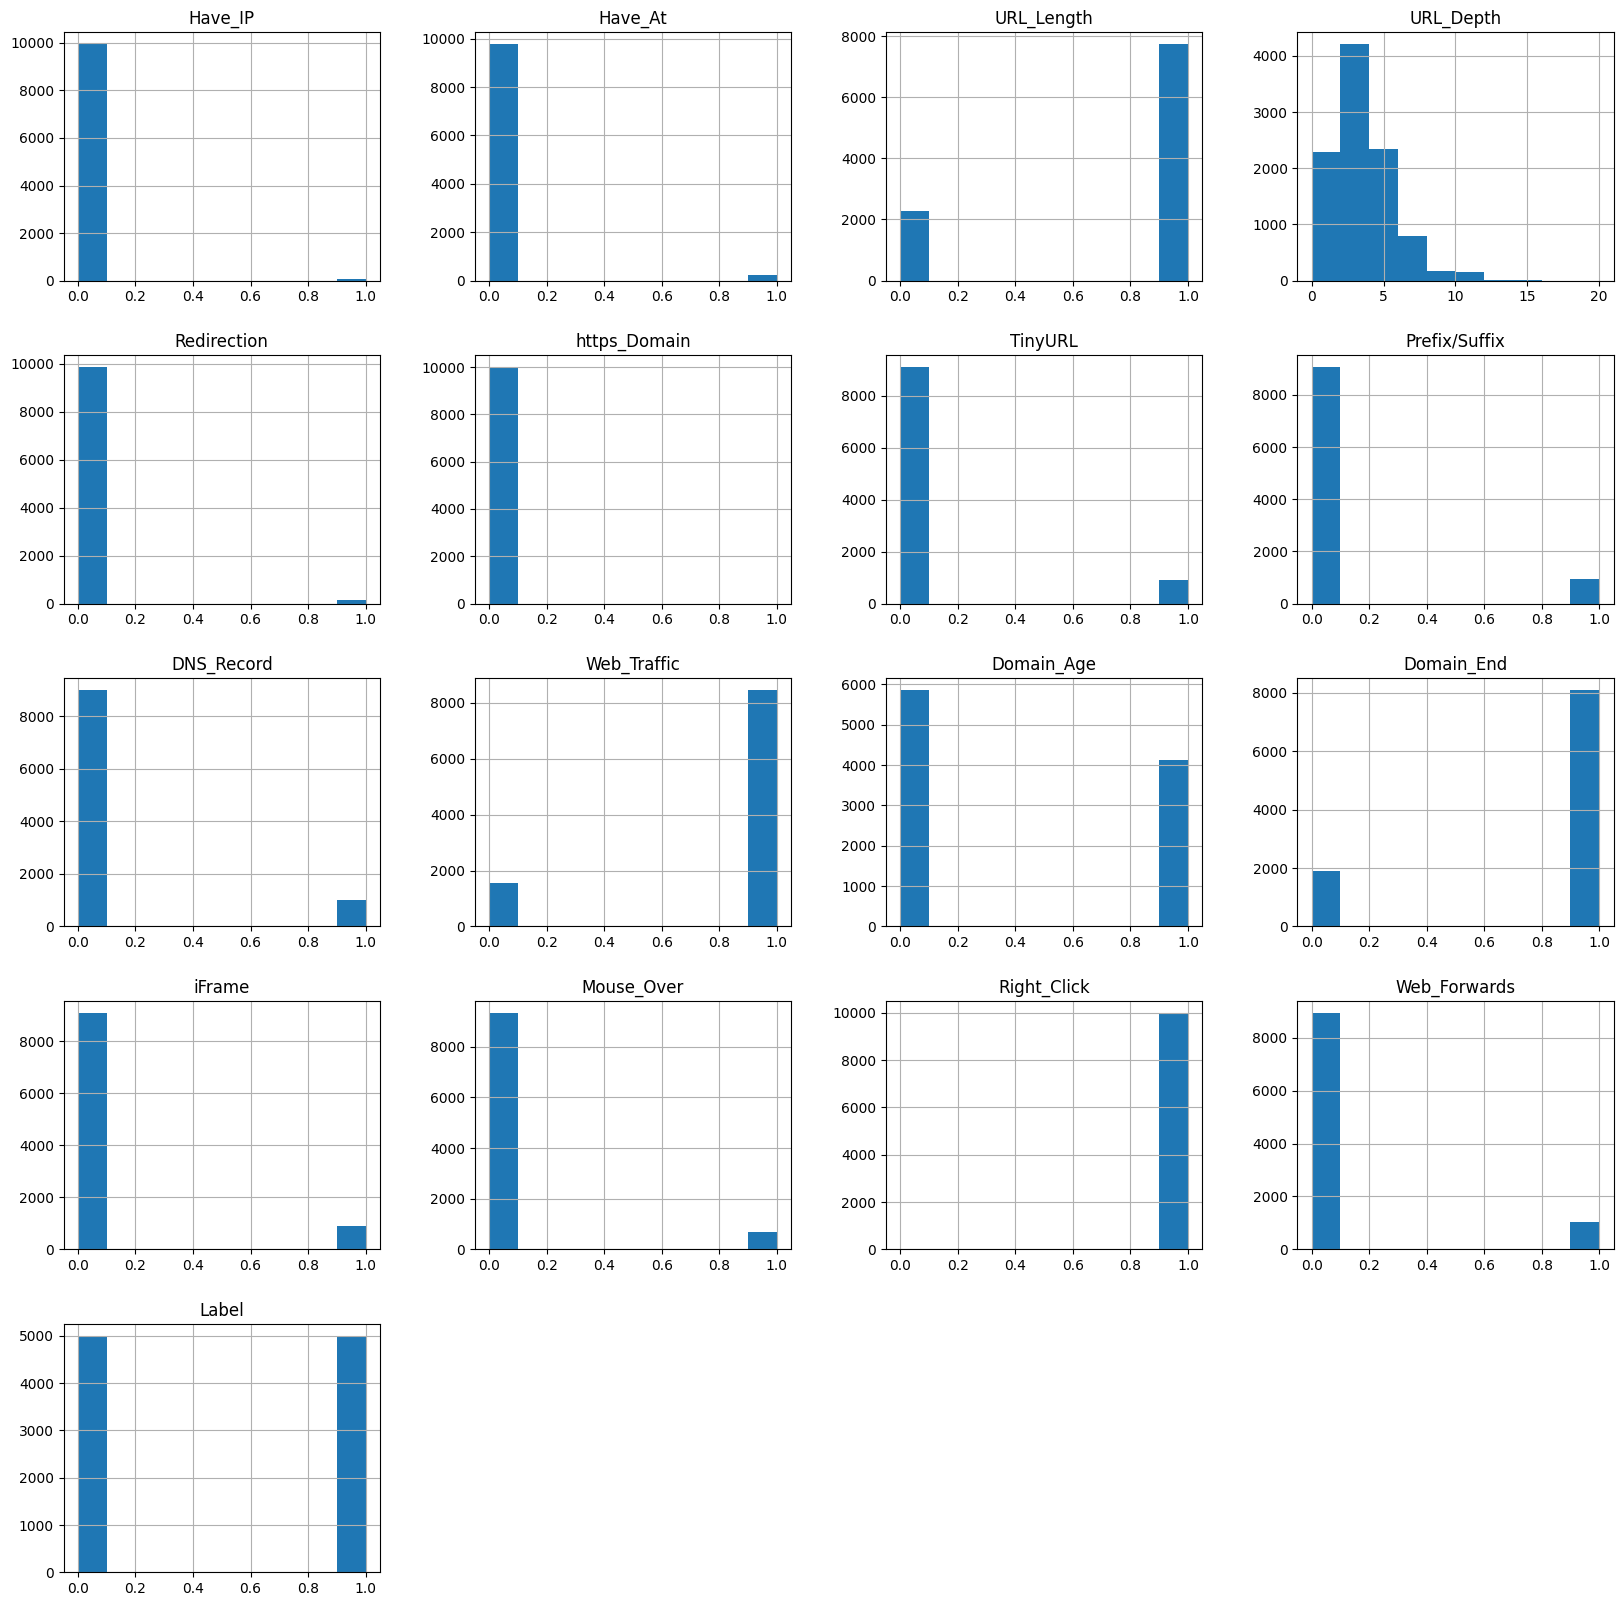

In [11]:
df.hist(figsize=(20,20))
plt.show()

# 3. Correlation Analysis

Pearson correlation is used to examine the linear relationship between the extracted phishing features.

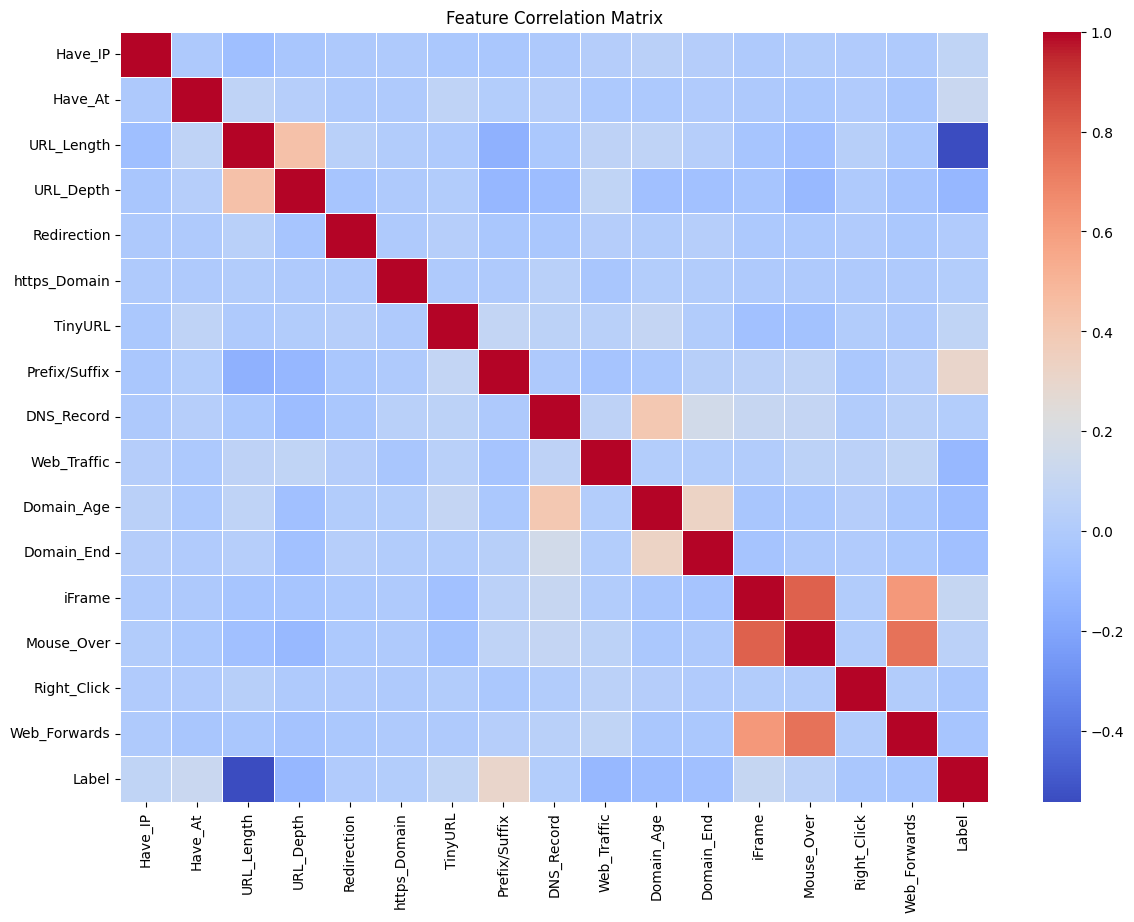

In [19]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=False,
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")
plt.show()

### Missing Values

In [20]:
missing = df.isnull().sum()

print(missing)

Domain           0
Have_IP          0
Have_At          0
URL_Length       0
URL_Depth        0
Redirection      0
https_Domain     0
TinyURL          0
Prefix/Suffix    0
DNS_Record       0
Web_Traffic      0
Domain_Age       0
Domain_End       0
iFrame           0
Mouse_Over       0
Right_Click      0
Web_Forwards     0
Label            0
dtype: int64


### Missing Values Observation

The dataset contains no missing values, therefore no imputation was required.

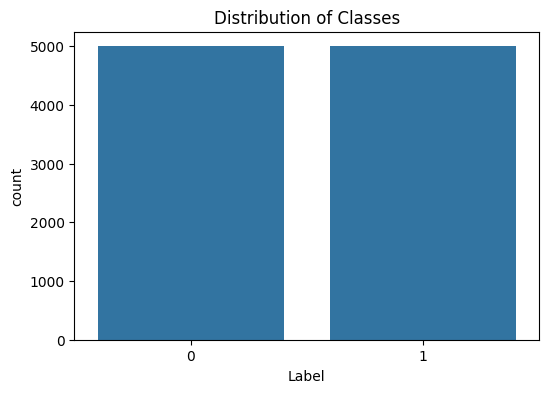

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Label")

plt.title("Distribution of Classes")
plt.show()

### Class Balance Observation

This dataset is approximately balanced between phishing and legitimate websites.

# 4. Outlier Analysis

Boxplots are used to identify potential outliers in the numerical features.

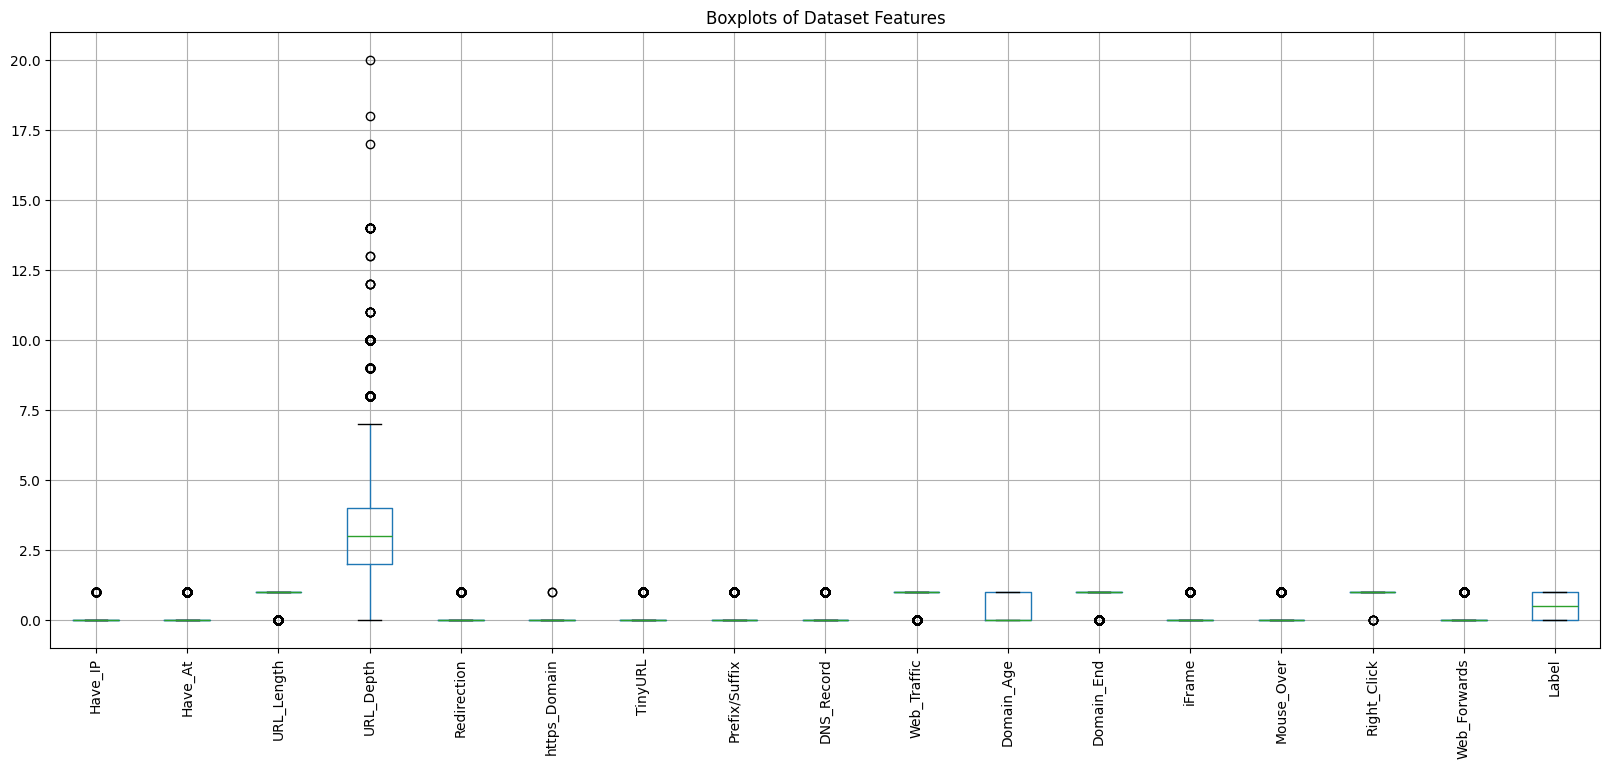

In [25]:
plt.figure(figsize=(20,8))

df.boxplot(rot=90)

plt.title("Boxplots of Dataset Features")
plt.show()

# 5. Feature Relationships

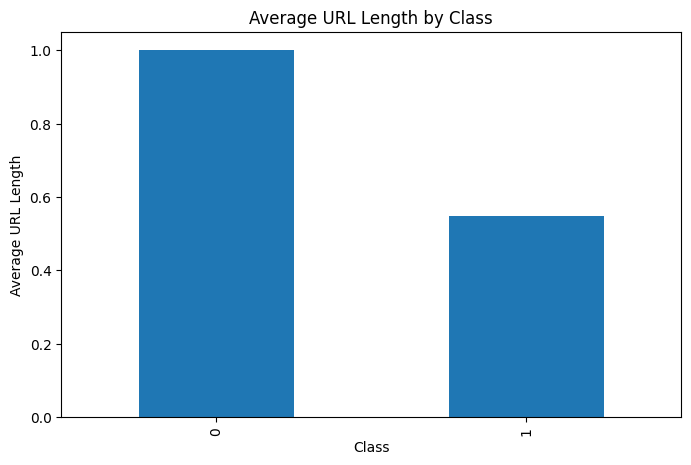

In [26]:
plt.figure(figsize=(8,5))

df.groupby("Label")["URL_Length"].mean().plot(kind="bar")

plt.title("Average URL Length by Class")
plt.xlabel("Class")
plt.ylabel("Average URL Length")

plt.show()

# 6. Data Preparation

In [33]:
# Features and target
X = df.drop(columns=["Domain", "Label"])
y = df["Label"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(8000, 17)
(2000, 17)


# 7. Feature Scaling

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 8. Logistic Regression

Logistic Regression is used as a baseline classification model for phishing website detection.

In [36]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [37]:
y_pred = logistic_model.predict(X_test_scaled)

In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    matthews_corrcoef,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("MCC      :", matthews_corrcoef(y_test, y_pred))

y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.7965
Precision: 0.9229671897289586
Recall   : 0.647
F1 Score : 0.7607289829512052
MCC      : 0.6214284167549268
ROC AUC  : 0.8743975


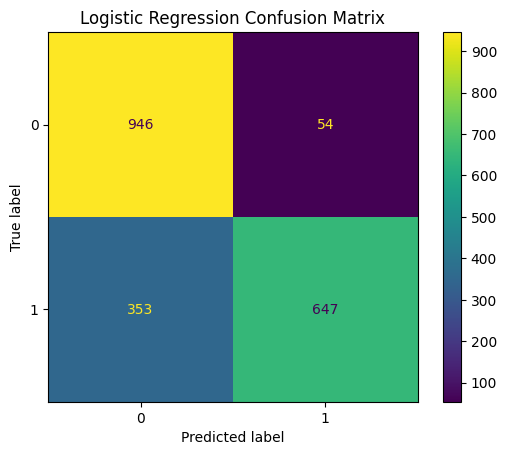

In [39]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# 9. Decision Tree

In [40]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

In [41]:
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("MCC      :", matthews_corrcoef(y_test, y_pred_dt))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_dt))

Accuracy : 0.865
Precision: 0.9254079254079254
Recall   : 0.794
F1 Score : 0.8546824542518837
MCC      : 0.7374730670350451
ROC AUC  : 0.9168395


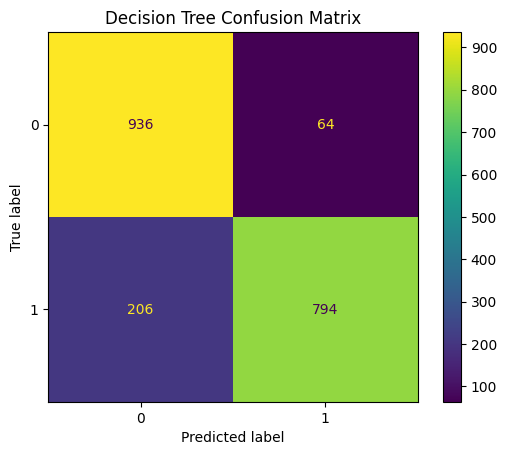

In [42]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt)
plt.title("Decision Tree Confusion Matrix")
plt.show()

# 10. Random Forest

Random Forest is an ensemble learning method that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [44]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("MCC      :", matthews_corrcoef(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.867
Precision: 0.9247685185185185
Recall   : 0.799
F1 Score : 0.8572961373390557
MCC      : 0.7408836708413495
ROC AUC  : 0.9257495000000001


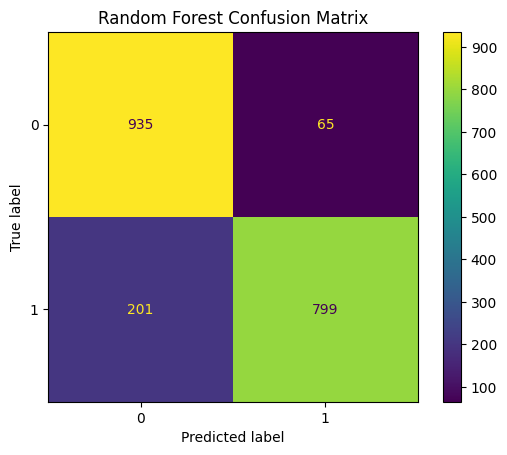

In [45]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Random Forest Confusion Matrix")
plt.show()

In [46]:
import xgboost

# 11. XGBoost

XGBoost is a gradient boosting algorithm that often achieves state-of-the-art performance on structured datasets.

In [47]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

In [48]:
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("MCC      :", matthews_corrcoef(y_test, y_pred_xgb))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_xgb))

Accuracy : 0.8625
Precision: 0.9713914174252276
Recall   : 0.747
F1 Score : 0.8445449406444319
MCC      : 0.7451536107053237
ROC AUC  : 0.9203224999999999


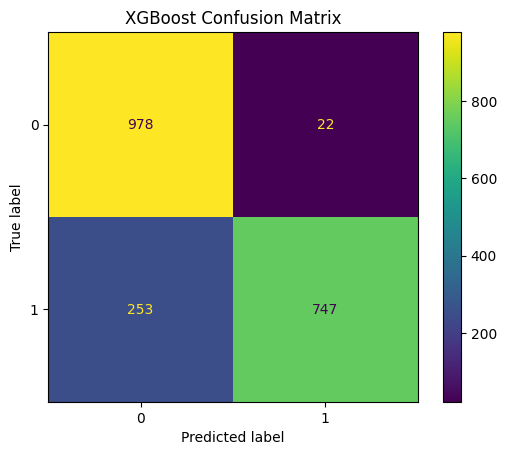

In [49]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)

plt.title("XGBoost Confusion Matrix")
plt.show()

The following table summarizes the performance of all trained machine learning models using the selected evaluation metrics.

# 12. Model Comparison

The following table summarizes the performance

In [50]:
results = {
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],
    "MCC": [
        matthews_corrcoef(y_test, y_pred),
        matthews_corrcoef(y_test, y_pred_dt),
        matthews_corrcoef(y_test, y_pred_rf),
        matthews_corrcoef(y_test, y_pred_xgb)
    ]
}

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.7965,0.922967,0.647,0.760729,0.621428
1,Decision Tree,0.8650,0.925408,0.794,0.854682,0.737473
2,Random Forest,0.8670,0.924769,0.799,0.857296,0.740884
3,XGBoost,0.8625,0.971391,0.747,0.844545,0.745154


In [55]:
results_df = results_df.round(4)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,MCC
0,Logistic Regression,0.7965,0.9230,0.647,0.7607,0.6214
1,Decision Tree,0.8650,0.9254,0.794,0.8547,0.7375
2,Random Forest,0.8670,0.9248,0.799,0.8573,0.7409
3,XGBoost,0.8625,0.9714,0.747,0.8445,0.7452


## Discussion

Random Forest achieved the highest overall performance with the best balance between Precision, Recall and F1-score.

Although XGBoost obtained the highest Precision, its Recall was lower than Random Forest, meaning it missed more phishing websites.

Since phishing detection prioritizes identifying malicious websites, Recall is a particularly important evaluation metric.

# 13. Feature Importance Analysis



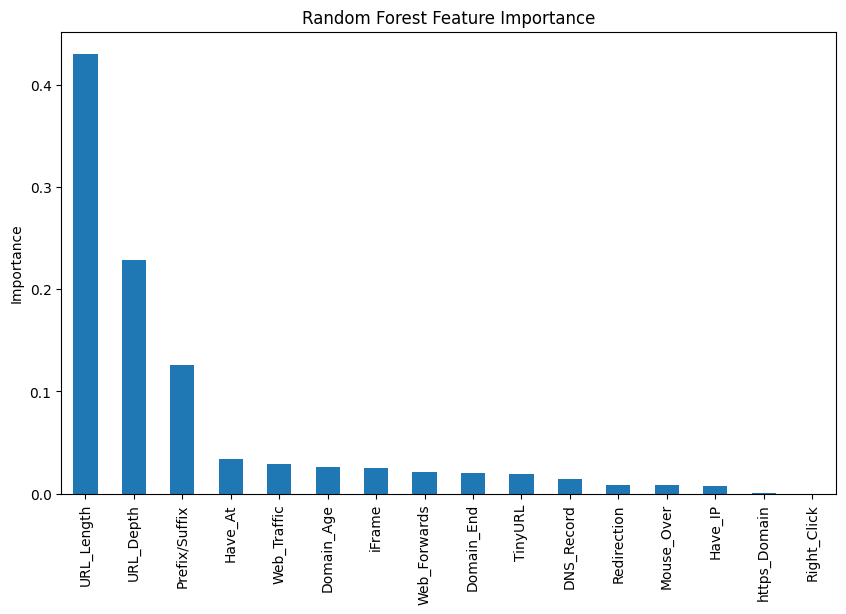

In [51]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance.plot(kind="bar")

plt.title("Random Forest Feature Importance")

plt.ylabel("Importance")

plt.show()

In [54]:
importance

,0
URL_Length,0.430598
URL_Depth,0.229137
Prefix/Suffix,0.125695
Have_At,0.033626
Web_Traffic,0.029434
Domain_Age,0.025791
iFrame,0.025013
Web_Forwards,0.021499
Domain_End,0.020155
TinyURL,0.018808


### Feature Importance Interpretation

The Random Forest feature importance analysis indicates that URL-based characteristics such as **URL_Length**, **URL_Depth**, and **Prefix/Suffix** contribute the most to phishing detection. These features capture common patterns found in phishing URLs, making them highly informative for classification. In contrast, features such as **Right_Click** and **https_Domain** have very low importance, suggesting that they contribute little to the predictive performance of the model.

# 14. ROC Curve Comparison

<Figure size 800x600 with 0 Axes>

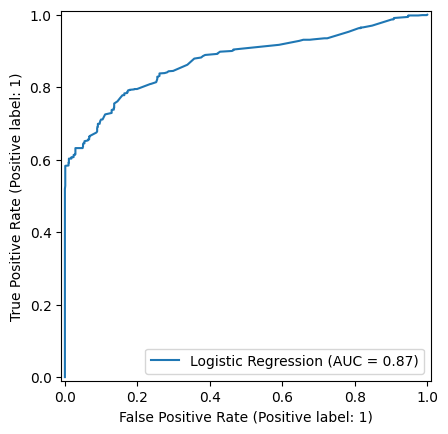

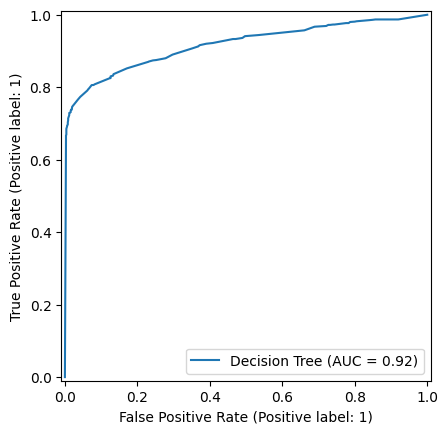

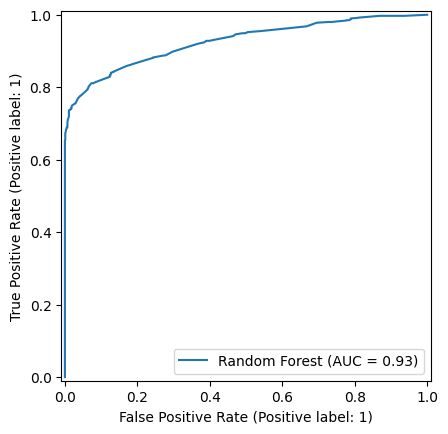

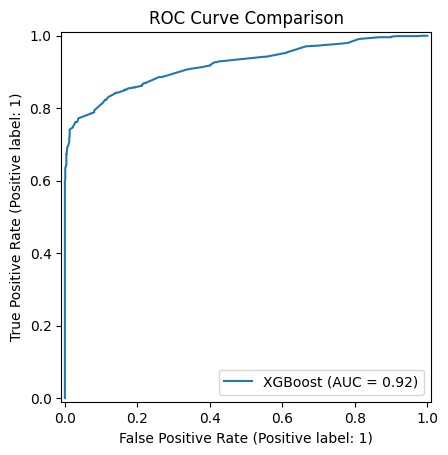

In [53]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,6))

RocCurveDisplay.from_predictions(y_test, y_prob, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_prob_dt, name="Decision Tree")
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="Random Forest")
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, name="XGBoost")

plt.title("ROC Curve Comparison")
plt.show()

# 15. Error Analysis

The models make two types of mistakes:

- False Positives: legitimate websites classified as phishing.
- False Negatives: phishing websites classified as legitimate.

For phishing detection, False Negatives are generally more dangerous because malicious websites remain undetected and may deceive users.

# 16. Conclusions

This notebook reproduced and extended the original phishing website detection project.

Four machine learning models were trained and compared.

The evaluation demonstrates that ensemble-based models achieve better performance than the baseline Logistic Regression model.

Additional analyses, including feature importance, confusion matrices, multiple evaluation metrics, and error analysis, provide a more comprehensive assessment than the original implementation.

## Future Work

Possible future improvements include:

- Testing additional machine learning algorithms such as LightGBM or CatBoost.
- Using larger and more recent phishing datasets.
- Performing hyperparameter optimization.
- Building a real-time browser extension for phishing detection.
- Evaluating the model on imbalanced datasets that better reflect real-world phishing prevalence.